# Кластеризация сигналов сцинтилляционного детектора

## 0. Окружение и параметры

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score

SEED = 0
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (9, 4)

INPUT = "Run200_Wave_0_1.txt"

N_BASE    = 50
PEAK      = 150
TAIL      = 250
SHORT_GATE = 5
AMP_SAT   = 14000
AREA_MIN  = 30

## 1. Загрузка и EDA

In [2]:
raw = pd.read_csv(INPUT, sep=" ", header=None, skipinitialspace=True)
meta = raw.iloc[:, :4]
sig = raw.iloc[:, 4:4 + 500].to_numpy(dtype=float)
print("Сигналов:", sig.shape[0], ", отсчётов:", sig.shape[1])
print("Метаданные (примеры строк):"); print(meta.head(3).to_string(index=False))
raw.iloc[:3, :8]

Сигналов: 23479 , отсчётов: 500
Метаданные (примеры строк):
      0   1   2   3
2890276 357 113 500
4928764 740 359 500
9630204 162 499 500


,0,1,2,3,4,5,6,7
0,2890276,357,113,500,14820,14823,14824,14822
1,4928764,740,359,500,14820,14822,14820,14826
2,9630204,162,499,500,14820,14820,14822,14825


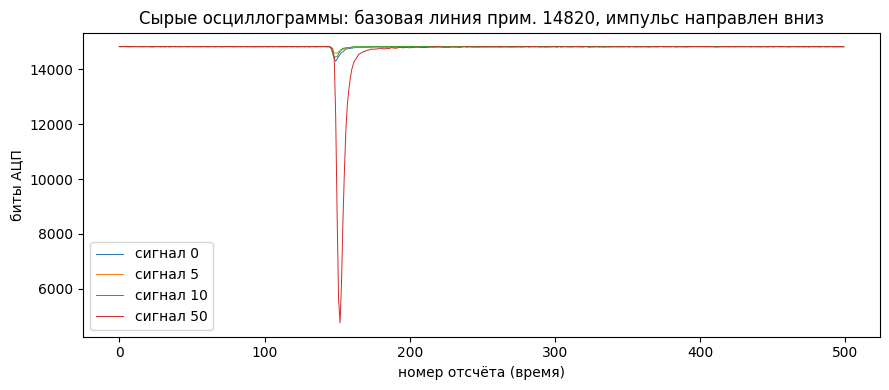

In [4]:
# несколько сырых осциллограмм
for i in [0, 5, 10, 50]:
    plt.plot(sig[i], lw=0.7, label=f"сигнал {i}")
plt.title("Сырые осциллограммы: базовая линия прим. 14820, импульс направлен вниз")
plt.xlabel("номер отсчёта (время)"); plt.ylabel("биты АЦП"); plt.legend()
plt.tight_layout(); plt.show()

**Промежуточный вывод.** В датасете 23 479 сигналов, у каждого по 500 отсчётов. Базовая линия держится около 14820, сам импульс выглядит как короткая просадка вниз с максимумом примерно у 150-го отсчёта. Поэтому дальше работаю не с сырыми 500 точками напрямую, а с признаками, которые описывают амплитуду, площадь и форму хвоста. Первые 4 столбца — служебные параметры ФЭУ; для разделения типов частиц они заметной пользы не дали, поэтому в модель их не добавляю.


## 2. Предобработка
Базовую линию оцениваем по первым 50 отсчётам, вычитаем и переворачиваем сигнал (импульс становится положительным пиком). Проверяем выравнивание пиков.

Позиция пика: медиана=150, 5-95%: 147..151


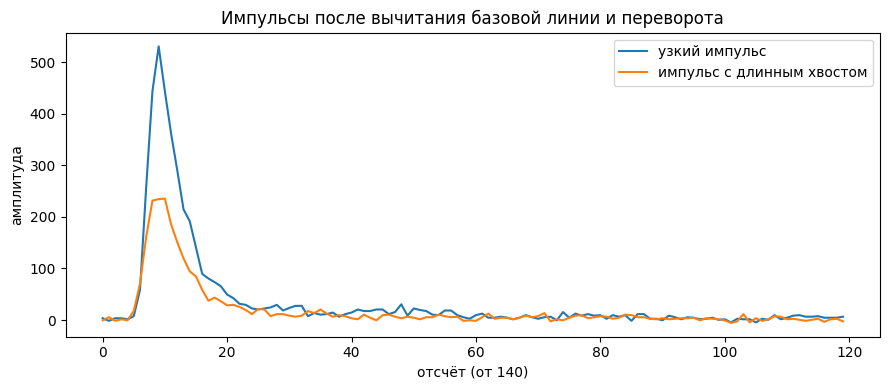

In [5]:
baseline = sig[:, :N_BASE].mean(axis=1, keepdims=True)
pulse = baseline - sig
peak_pos = pulse.argmax(axis=1)
print("Позиция пика: медиана=%d, 5-95%%: %d..%d"
      % (np.median(peak_pos), np.percentile(peak_pos, 5), np.percentile(peak_pos, 95)))

plt.plot(pulse[0, 140:260], label="узкий импульс")
plt.plot(pulse[5, 140:260], label="импульс с длинным хвостом")
plt.title("Импульсы после вычитания базовой линии и переворота")
plt.xlabel("отсчёт (от 140)"); plt.ylabel("амплитуда"); plt.legend()
plt.tight_layout(); plt.show()

**Промежуточный вывод.** Положение пика почти не меняется: основная масса лежит в диапазоне 147–151. Значит, сигналы уже достаточно хорошо синхронизованы, и отдельное выравнивание не требуется. После вычитания baseline лучше всего видно различие в хвосте импульса — одни сигналы затухают быстрее, другие медленнее.


## 3. Feature Engineering
Извлекаем признаки трёх групп:
- энергия: амплитуда, площадь (log — распределения скошены);
- форма: PSD = (площадь − короткое_окно)/площадь и профиль доли заряда в окнах хвоста 2..250 отсчётов (нормировка на полный заряд убирает зависимость от энергии);
- время высвечивания τ: из лог-линейной аппроксимации хвоста (физический параметр спада, по образцу экспоненциальной модели импульса).

`SHORT_GATE=5` для PSD выбран на шаге 4 по максимальной глубине провала между пиками гистограммы.

In [6]:
area = pulse[:, PEAK:PEAK + TAIL].sum(axis=1)
amp = pulse.max(axis=1)
safe_area = np.where(area <= 0, 1.0, area)

# PSD
short = pulse[:, PEAK:PEAK + SHORT_GATE].sum(axis=1)
psd = (area - short) / safe_area

# профиль формы: доля заряда в окнах хвоста (energy-independent)
shape_edges = [2, 4, 6, 8, 10, 14, 20, 30, 50, 80, 150, 250]
shape_profile = np.column_stack([pulse[:, PEAK:PEAK + k].sum(1) / safe_area
                                 for k in shape_edges])

# время высвечивания tau: log-линейный фит хвоста (3..40 отсчётов после пика)
lo, hi = 3, 40
seg = np.clip(pulse[:, PEAK + lo:PEAK + hi], 1e-6, None)
tt = np.arange(lo, hi) - np.arange(lo, hi).mean()
slope = (np.log(seg) * tt).sum(1) / (tt ** 2).sum()
tau_fit = np.clip(np.where(slope < 0, -1.0 / slope, 0.0), 0, 200)
tau_proxy = np.where((amp > 0) & (area > 0), area / amp, 0.0)

feat = pd.DataFrame({"amp": amp, "area": area, "psd": psd,
                     "tau_fit": tau_fit, "tau_proxy": tau_proxy})
feat.describe().round(3)

,amp,area,psd,tau_fit,tau_proxy
count,23479.000,23479.000,23479.000,23479.000,23479.000
mean,1835.105,11245.480,0.307,8.593,5.671
std,2389.301,14904.547,4.388,4.348,1.586
min,104.300,-138.000,-249.300,0.000,0.000
25%,308.160,1553.000,0.302,5.629,4.639
50%,812.540,4782.000,0.437,8.236,5.687
75%,2315.050,14738.000,0.509,11.217,7.057
max,14824.840,110627.000,0.816,200.000,11.010


**Промежуточный вывод.** Вместо 500 исходных отсчётов дальше использую небольшой набор признаков: амплитуду и площадь, PSD, профиль хвоста и оценки времени спада. Нормировка хвостового профиля на полный заряд нужна для того, чтобы признак описывал именно форму импульса, а не просто его энергию.


## 4. Подбор признака PSD и анализ
Главная проверка — гистограмма PSD должна быть бимодальной. Короткое окно PSD подбираем по глубине провала между пиками, чем глубже, тем чище разделение.

In [7]:
def dip_ratio(short_len):
    s = pulse[:, PEAK:PEAK + short_len].sum(1)
    p = (area - s) / safe_area
    m = (area > AREA_MIN) & (amp < AMP_SAT) & (p > 0) & (p < 1)
    h, e = np.histogram(p[m], bins=300, range=(0, 1))
    hs = gaussian_filter1d(h.astype(float), 3); c = (e[:-1] + e[1:]) / 2
    pk = [i for i in range(1, len(hs) - 1) if hs[i] > hs[i-1] and hs[i] > hs[i+1] and hs[i] > 40]
    if len(pk) < 2: return None
    p1, p2 = pk[0], pk[-1]; vi = p1 + np.argmin(hs[p1:p2])
    return min(hs[p1], hs[p2]) / max(hs[vi], 1), c[vi]

print("short_gate -> (глубина провала, положение долины):")
for sl in [5, 8, 10, 15, 20]:
    r = dip_ratio(sl); print(f"  {sl:2d}: {None if r is None else (round(r[0],1), round(r[1],3))}")

short_gate -> (глубина провала, положение долины):
   5: (np.float64(6.0), np.float64(0.385))
   8: (np.float64(3.9), np.float64(0.255))
  10: (np.float64(3.4), np.float64(0.208))
  15: (np.float64(3.1), np.float64(0.155))
  20: (np.float64(3.0), np.float64(0.128))


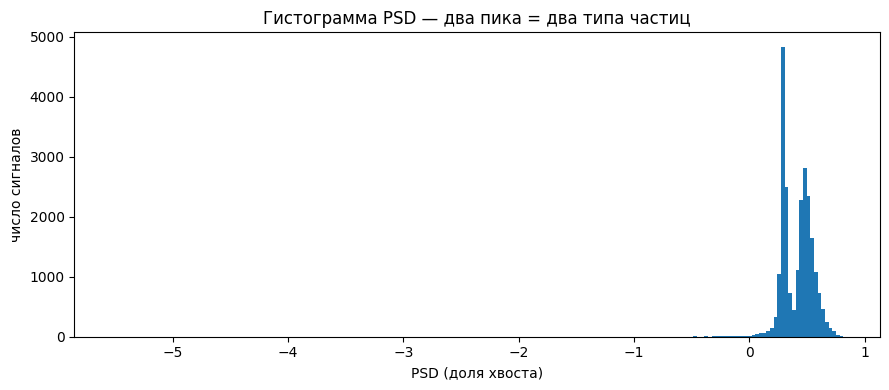

In [8]:
# гистограмма PSD при выбранном коротком окне
m = (feat.area > AREA_MIN) & (feat.amp < AMP_SAT)
plt.hist(feat.psd[m], bins=200)
plt.title("Гистограмма PSD — два пика = два типа частиц")
plt.xlabel("PSD (доля хвоста)"); plt.ylabel("число сигналов")
plt.tight_layout(); plt.show()

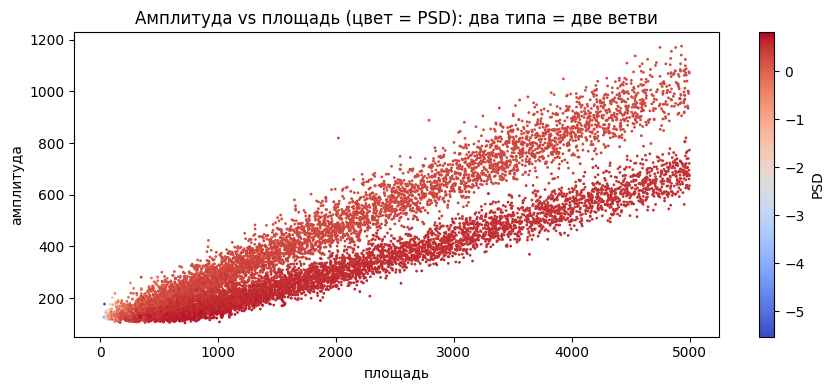

In [9]:
# диаграмма амплитуда vs площадь, цвет = PSD: две диагональные ветви
mm = m & (feat.area < 5000)
plt.scatter(feat.area[mm], feat.amp[mm], s=1, c=feat.psd[mm], cmap="coolwarm")
plt.colorbar(label="PSD"); plt.title("Амплитуда vs площадь (цвет = PSD): два типа = две ветви")
plt.xlabel("площадь"); plt.ylabel("амплитуда"); plt.tight_layout(); plt.show()

**Промежуточный вывод.** Лучшим из проверенных коротких окон оказался `short_gate=5`: у него самый глубокий провал между двумя пиками PSD (примерно 6 против 3.4–3.9 у более длинных окон). Это хороший признак того, что в данных действительно есть две основные группы сигналов. На графике амплитуда–площадь также видны две диагональные ветви: при близкой площади амплитуда отличается, то есть различается форма импульса. Одной энергии для разделения здесь недостаточно.


## 5. Оценка важности признаков
Сделаю грубую проверку: беру предварительную метку по PSD и смотрю, насколько средние значения признаков различаются между двумя группами. Это не финальная оценка важности, а быстрый sanity check перед выбором признаков для модели.


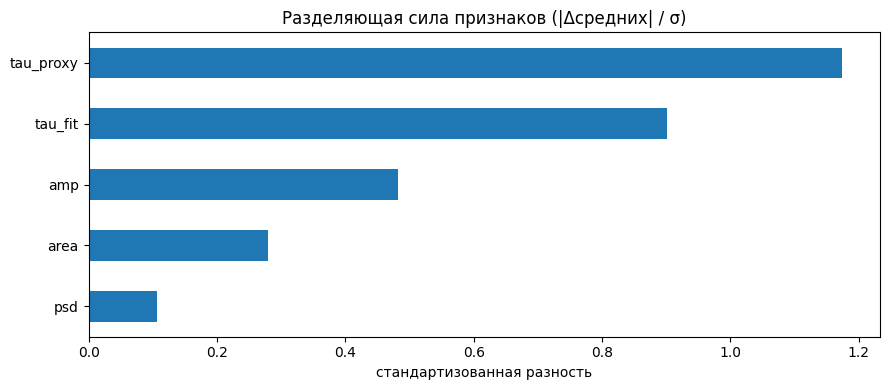

tau_proxy    1.174
tau_fit      0.901
amp          0.483
area         0.280
psd          0.107
dtype: float64

In [10]:
prelim = (feat.psd >= dip_ratio(SHORT_GATE)[1]).astype(int)
cols = ["psd", "tau_fit", "tau_proxy", "amp", "area"]
imp = {}
for col in cols:
    x = feat[col].to_numpy(float)
    g0, g1 = x[prelim == 0], x[prelim == 1]
    imp[col] = abs(g0.mean() - g1.mean()) / (x.std() + 1e-9)
imp = pd.Series(imp).sort_values(ascending=False)
imp.plot.barh(); plt.title("Разделяющая сила признаков (|Δсредних| / σ)")
plt.xlabel("стандартизованная разность"); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()
imp.round(3)

**Промежуточный вывод.** По этой проверке сильнее всего различаются признаки, связанные со спадом хвоста: `tau_proxy` и `tau_fit`. Амплитуда и площадь тоже немного отличаются, но заметно слабее. Сам PSD в этой таблице не выглядит самым сильным признаком из-за выбранной нормировки и большого разброса внутри групп, поэтому я не использую его как единственный ответ. В финальной схеме PSD нужен как понятная стартовая граница между двумя модами, а уточнение делается уже по полному набору признаков формы и времени спада.


## 6. Аномалии и третий кластер
По условию третий кластер соответствует сигналам, которые нельзя уверенно отнести к одному из двух физических типов. Поэтому отдельно проверяю самые простые технические выбросы: насыщение АЦП и почти пустые импульсы.


In [12]:
anomaly = (feat.amp >= AMP_SAT) | (feat.area <= AREA_MIN)
print("насыщение АЦП:", int((feat.amp >= AMP_SAT).sum()),
      "| пустые:", int((feat.area <= AREA_MIN).sum()),
      "| всего аномалий:", int(anomaly.sum()))

насыщение АЦП: 12 | пустые: 21 | всего аномалий: 33


**Промежуточный вывод.** Явных технических аномалий получилось всего 33 из 23 479 сигналов: 12 с насыщением и 21 почти пустой. Это слишком мало для устойчивого отдельного кластера. Я проверяла вариант, где такие сигналы отправляются в `cluster=2`, но на лидерборде он давал результат хуже. Поэтому финальный leaderboard-сабмит ниже использует только два устойчивых физических кластера — `0` и `1`.

Это сознательное решение, номер `2` в итоговом файле не используется, потому что в этих данных третий кластер не проявился как отдельная плотная группа.


## 7. Сравнение моделей кластеризации
Дальше сравниваю несколько способов разделить две основные группы в пространстве признаков формы (`shape_profile + tau`).
- KMeans, GMM и агломеративная кластеризация — базовые варианты «из коробки»;
- дискриминант Фишера — более контролируемая граница между двумя группами формы, с порогом по долине гистограммы проекции.

Для внутренней проверки считаю silhouette и Calinski-Harabasz. Перед этим признаки стандартизую.


In [13]:
valid = (feat.area > AREA_MIN) & (feat.amp < AMP_SAT)
F = np.column_stack([shape_profile, np.log1p(tau_proxy), np.log1p(tau_fit)])
Z = np.clip(StandardScaler().fit(F[valid]).transform(F), -8, 8)

def orient(labels):
    return labels if feat.psd[labels == 1].mean() < feat.psd[labels == 0].mean() else 1 - labels

def scores(labels):
    sub = np.random.RandomState(SEED).choice(len(Z), 5000, replace=False)
    return round(silhouette_score(Z[sub], labels[sub]), 3), round(calinski_harabasz_score(Z, labels), 1)

results = {}
km = orient(KMeans(2, n_init=10, random_state=SEED).fit_predict(Z));      results["KMeans"] = scores(km)
gm = orient(GaussianMixture(2, n_init=8, random_state=SEED).fit(Z).predict(Z)); results["GMM"] = scores(gm)
ag = AgglomerativeClustering(2).fit_predict(Z[::6]);
ag_s = (round(silhouette_score(Z[::6], ag), 3), round(calinski_harabasz_score(Z[::6], ag), 1)); results["Agglomerative"] = ag_s
pd.DataFrame(results, index=["silhouette", "calinski_harabasz"]).T

,silhouette,calinski_harabasz
KMeans,0.505,17745.1
GMM,0.306,1321.3
Agglomerative,0.494,2706.9


**Промежуточный вывод.** По внутренним метрикам KMeans выглядит неплохо, но визуально и по пробным сабмитам такие варианты часто ловят не тот эффект: они склонны разделять часть данных по энергии/масштабу, а не по типу импульса. Поэтому я не выбираю модель только по silhouette или Calinski-Harabasz. Для этой задачи важнее сохранить физически понятную границу по форме сигнала, поэтому финальный вариант строю вокруг адаптивного PSD и дискриминанта Фишера.


## 8. Лучшая модель: адаптивный PSD + дискриминант Фишера

Финальный вариант состоит из двух шагов.

1. Сначала строю адаптивную границу PSD. Положение долины между пиками немного зависит от амплитуды, поэтому один фиксированный порог даёт систематические ошибки на краях диапазона. Чтобы это учесть, нахожу долину PSD в диапазонах `log(амплитуды)` и сглаживаю полученную кривую.
2. Затем уточняю разбиение дискриминантом Фишера по полному набору признаков формы: хвостовой профиль + оценки времени спада. В качестве стартовой разметки беру адаптивный PSD, после чего граница пересчитывается по проекции. Двух итераций оказалось достаточно, дальше метки практически не менялись.


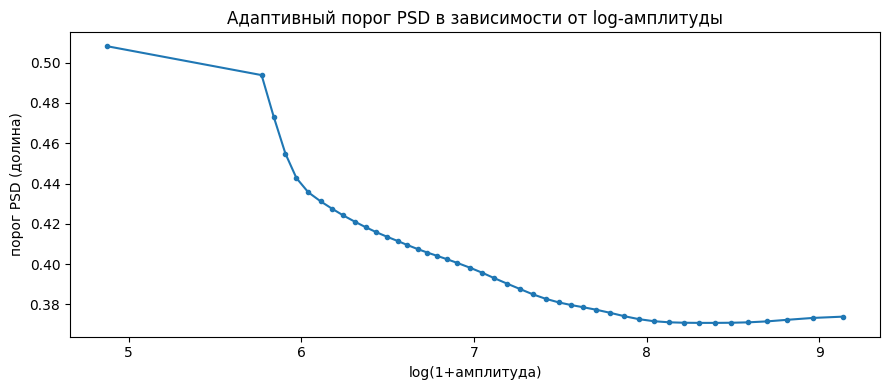

In [14]:
la = np.log1p(np.clip(amp, 0, None))
NB = 60
bins = np.quantile(la[valid], np.linspace(0, 1, NB + 1))
xs, ts = [], []
for i in range(NB):
    mm = valid & (la >= bins[i]) & (la < bins[i + 1])
    pv = psd[mm]; pv = pv[(pv > 0) & (pv < 1)]
    if len(pv) < 40: continue
    h, e = np.histogram(pv, bins=120, range=(0, 1)); hs = gaussian_filter1d(h.astype(float), 3)
    pk = [j for j in range(1, len(hs) - 1) if hs[j] > hs[j-1] and hs[j] > hs[j+1] and hs[j] > 8]
    c = (e[:-1] + e[1:]) / 2
    if len(pk) >= 2:
        p1, p2 = pk[0], pk[-1]; vi = p1 + np.argmin(hs[p1:p2])
        xs.append(0.5 * (bins[i] + bins[i + 1])); ts.append(c[vi])
xs, ts = np.array(xs), np.array(ts); o = np.argsort(xs)
thr_curve = gaussian_filter1d(ts[o], 2)
thr_per_signal = np.interp(la, xs[o], thr_curve)
seed = np.where(psd < thr_per_signal, 1, 0)

plt.plot(xs[o], thr_curve, marker="o", ms=3)
plt.title("Адаптивный порог PSD в зависимости от log-амплитуды")
plt.xlabel("log(1+амплитуда)"); plt.ylabel("порог PSD (долина)")
plt.tight_layout(); plt.show()

In [15]:
def fisher_split(Z, labels, valid):
    g0 = (labels == 0) & valid; g1 = (labels == 1) & valid
    m0, m1 = Z[g0].mean(0), Z[g1].mean(0)
    S = np.cov(Z[g0].T) * g0.sum() + np.cov(Z[g1].T) * g1.sum()
    w = np.linalg.solve(S + 1e-3 * np.eye(Z.shape[1]), m1 - m0)
    proj = Z @ w
    pv = proj[valid]; h, e = np.histogram(pv, bins=300); hs = gaussian_filter1d(h.astype(float), 3)
    pk = [j for j in range(1, len(hs) - 1) if hs[j] > hs[j-1] and hs[j] > hs[j+1] and hs[j] > 40]
    c = (e[:-1] + e[1:]) / 2
    cut = c[pk[0] + np.argmin(hs[pk[0]:pk[-1]])] if len(pk) >= 2 else np.median(pv)
    labels2 = np.where(proj < cut, 1, 0)
    return labels2 if feat.psd[labels2 == 1].mean() < feat.psd[labels2 == 0].mean() else 1 - labels2

labels = seed.copy()
for _ in range(2):
    labels = fisher_split(Z, labels, valid.to_numpy())
print("Итоговые размеры кластеров:", np.bincount(labels).tolist())
print("Сигналов уточнено относительно адаптивного PSD:", int((seed != labels).sum()))

Итоговые размеры кластеров: [12068, 11411]
Сигналов уточнено относительно адаптивного PSD: 809


**Промежуточный вывод.** Адаптивный PSD убирает часть ошибок фиксированного порога, а дискриминант Фишера дополнительно пересматривает 809 пограничных сигналов. Это как раз та зона, где два типа импульсов частично перекрываются и простое пороговое правило работает хуже.


## 9. Предсказание и формирование сабмишна

In [16]:
# Финальный leaderboard-сабмит: используем две устойчивые группы (0 и 1).
# Кластер 2 для 33 технических аномалий проверялся отдельно, но ухудшал public score.
submission = pd.DataFrame({"index": np.arange(len(labels)), "cluster": labels.astype(int)})
submission.to_csv("submission.csv", index=False)
print("Размеры кластеров:", submission.cluster.value_counts().sort_index().to_dict())
submission.head()


Размеры кластеров: {0: 12068, 1: 11411}


,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1


**Итог по сабмиту.** Получились два сопоставимых по размеру кластера: 12 068 и 11 411 сигналов. В финальном файле есть только метки `0` и `1`, потому что отдельный кластер технических аномалий слишком мал и ухудшал результат на Kaggle. Для текущей версии я трактую эти две группы как два физических типа сигналов — гамма-кванты и нейтроны.


## 10. Результат на лидерборде Kaggle


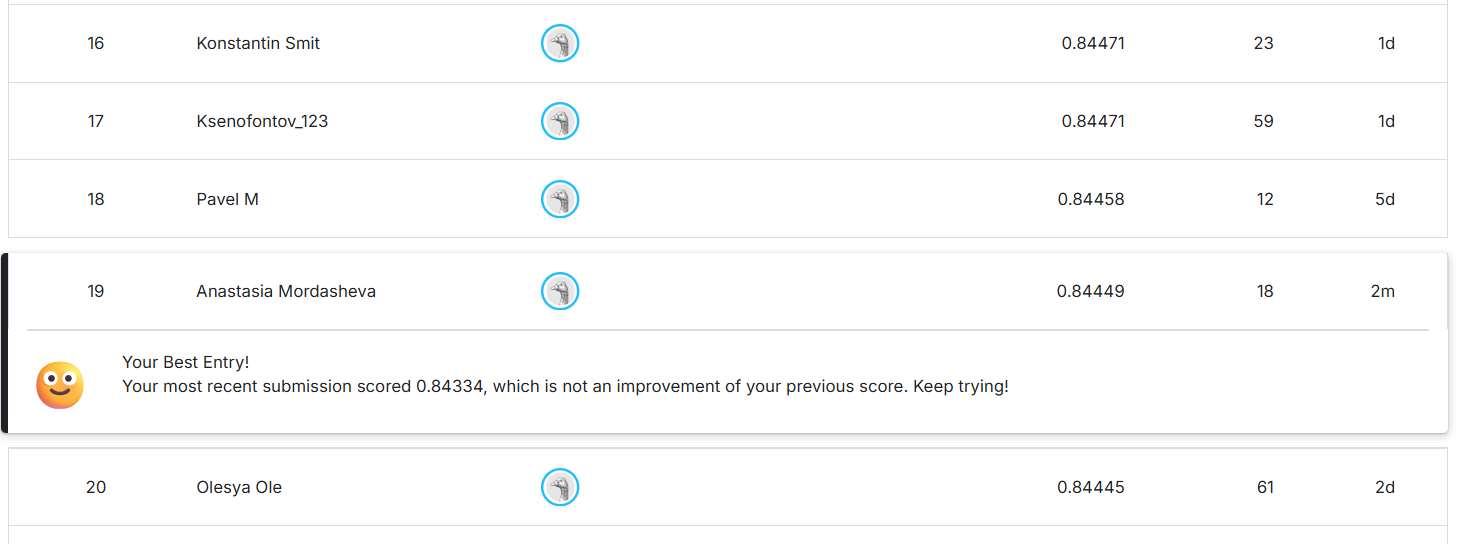

In [17]:
from pathlib import Path
from IPython.display import Image, display, Markdown

score_image = Path("kaggle_results.png")

display(Image(filename=str(score_image)))